# TP4 - Modelo de Hopfield
## Reconocimiento de patrones de letras con matrices 5×5

**Objetivo:**
- a. Almacenar 4 letras y recuperarlas desde versiones ruidosas, mostrando cada paso.
- b. Ingresar un patrón muy ruidoso e identificar un estado espúreo.

### ¿Cómo funciona la red de Hopfield?

La red de Hopfield es una red neuronal recurrente que funciona como **memoria asociativa**: dado un patrón incompleto o ruidoso, converge al patrón almacenado más cercano.

**Entrenamiento (Regla de Hebb):**
```
W = (1/N) · Σ_μ  ξ^μ (ξ^μ)ᵀ    con  W_ii = 0
```
- `N`: número de neuronas (25 para matrices 5×5)
- `ξ^μ`: patrón μ aplanado como vector de ±1

**Actualización asíncrona** (neurona por neurona):
```
s_i(t+1) = sign( Σ_j  W_ij · s_j(t) )
```
Se actualiza una neurona por vez en orden aleatorio, hasta que el estado no cambie.

**Estado espúreo:** atractor de la red que no corresponde a ningún patrón almacenado. Surge cuando el patrón de consulta es tan distinto de todos los patrones que la red converge a una mezcla o al negativo de un patrón.

## 1. Definición de los 4 patrones de letras

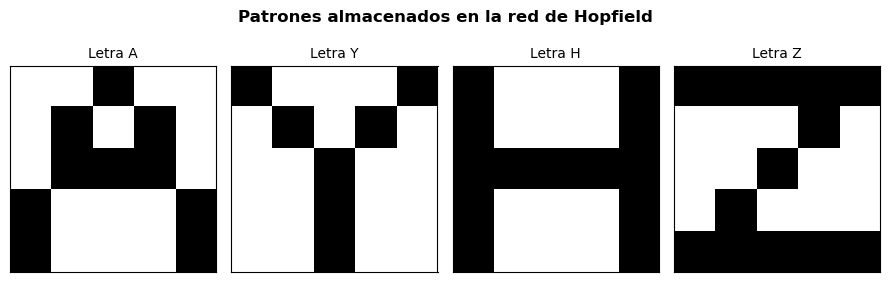

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# Patrones de letras 5x5 con valores 1 (pixel activo) y -1 (pixel inactivo)
patterns = {
    'A': np.array([
        [-1, -1,  1, -1, -1],
        [-1,  1, -1,  1, -1],
        [-1,  1,  1,  1, -1],
        [ 1, -1, -1, -1,  1],
        [ 1, -1, -1, -1,  1],
    ]),
    'Y': np.array([
        [ 1, -1, -1, -1,  1],
        [-1,  1, -1,  1, -1],
        [-1, -1,  1, -1, -1],
        [-1, -1,  1, -1, -1],
        [-1, -1,  1, -1, -1],
    ]),
    'H': np.array([
        [ 1, -1, -1, -1,  1],
        [ 1, -1, -1, -1,  1],
        [ 1,  1,  1,  1,  1],
        [ 1, -1, -1, -1,  1],
        [ 1, -1, -1, -1,  1],
    ]),
    'Z': np.array([
        [ 1,  1,  1,  1,  1],
        [-1, -1, -1,  1, -1],
        [-1, -1,  1, -1, -1],
        [-1,  1, -1, -1, -1],
        [ 1,  1,  1,  1,  1],
    ]),
}

pattern_names = list(patterns.keys())
pattern_list  = [patterns[k].flatten() for k in pattern_names]

# Función de visualización de un patrón
def plot_pattern(ax, pattern, title='', show_values=False):
    grid = pattern.reshape(5, 5)
    ax.imshow(grid, cmap='gray_r', vmin=-1, vmax=1, aspect='equal')
    if show_values:
        for i in range(5):
            for j in range(5):
                ax.text(j, i, str(int(grid[i, j])),
                        ha='center', va='center', fontsize=7,
                        color='white' if grid[i, j] == 1 else 'black')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Mostrar los 4 patrones originales
fig, axes = plt.subplots(1, 4, figsize=(9, 3))
for ax, name in zip(axes, pattern_names):
    plot_pattern(ax, patterns[name].flatten(), title=f'Letra {name}')
fig.suptitle('Patrones almacenados en la red de Hopfield', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Implementación de la red de Hopfield

In [8]:
class Hopfield:
    def __init__(self):
        self.W = None
        self.N = None

    def train(self, patterns):
        """
        Aprende los patrones usando la regla de Hebb.
        W = (1/N) * Σ_μ  ξ^μ (ξ^μ)ᵀ   con diagonal en cero.
        """
        self.N = len(patterns[0])
        self.W = np.zeros((self.N, self.N))
        for xi in patterns:
            xi = np.array(xi, dtype=float)
            self.W += np.outer(xi, xi)
        self.W /= self.N
        np.fill_diagonal(self.W, 0)  # sin auto-conexiones

    def energy(self, s):
        return -0.5 * s @ self.W @ s

    def predict(self, s_init, max_iter=20, seed=0):
        """
        Actualización asíncrona: neurona por neurona en orden aleatorio.
        Devuelve el historial de estados en cada paso completo (epoch).
        """
        rng = np.random.default_rng(seed)
        s = np.array(s_init, dtype=float)
        history = [s.copy()]

        for _ in range(max_iter):
            s_prev = s.copy()
            for i in rng.permutation(self.N):
                h = self.W[i] @ s          # campo local
                s[i] = 1.0 if h >= 0 else -1.0
            history.append(s.copy())
            if np.array_equal(s, s_prev):  # convergencia
                break

        return s, history


# Entrenar la red
net = Hopfield()
net.train(pattern_list)
print(f"Red entrenada con {len(pattern_list)} patrones de {net.N} neuronas cada uno.")
print(f"Capacidad teórica: {0.138 * net.N:.1f} patrones  (0.138 × N)")
print(f"\nMatriz de pesos W ({net.N}×{net.N}) — primeras 5 filas/columnas:")
print(np.round(net.W[:5, :5], 3))

Red entrenada con 4 patrones de 25 neuronas cada uno.
Capacidad teórica: 3.5 patrones  (0.138 × N)

Matriz de pesos W (25×25) — primeras 5 filas/columnas:
[[ 0.    0.   -0.08  0.    0.16]
 [ 0.    0.    0.08  0.16  0.  ]
 [-0.08  0.08  0.    0.08 -0.08]
 [ 0.    0.16  0.08  0.    0.  ]
 [ 0.16  0.   -0.08  0.    0.  ]]


## 3. Parte a — Recuperación desde patrones ruidosos

Para cada letra almacenada, generamos un patrón de consulta invirtiendo aleatoriamente el **20% de los bits** y dejamos que la red converja. Mostramos cada paso de la actualización asíncrona.

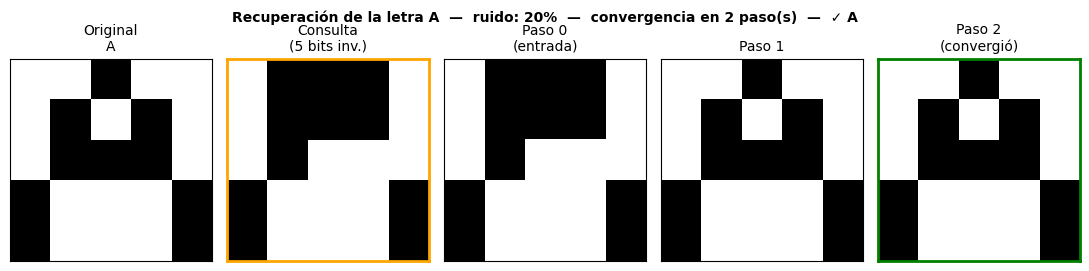

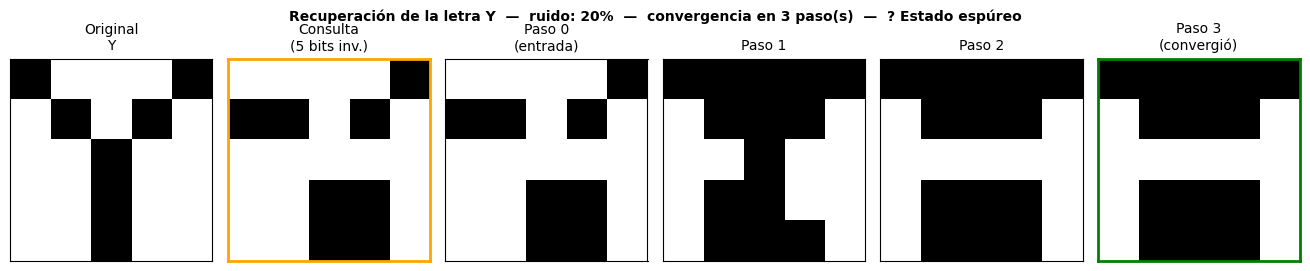

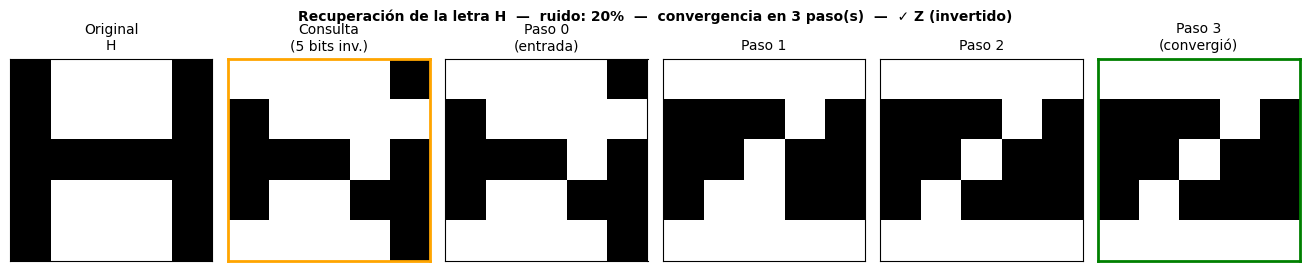

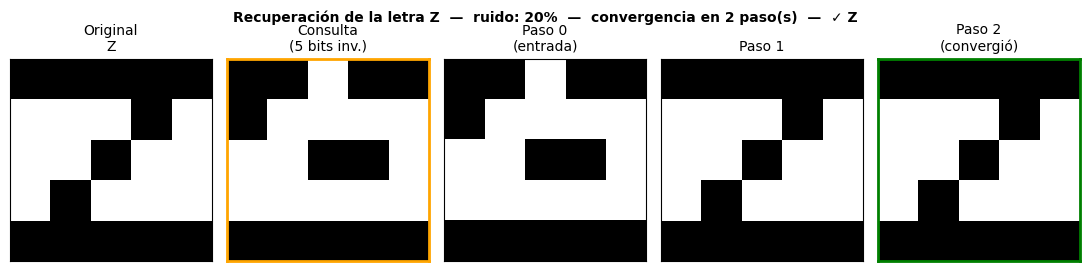

In [9]:
def add_noise(pattern, noise_level=0.2, seed=0):
    """Invierte 'noise_level' fracción de los bits del patrón."""
    rng = np.random.default_rng(seed)
    noisy = pattern.copy()
    n_flip = int(len(pattern) * noise_level)
    flip_idx = rng.choice(len(pattern), size=n_flip, replace=False)
    noisy[flip_idx] *= -1
    return noisy

def identify(state, pattern_list, pattern_names):
    """Identifica a qué letra almacenada corresponde el estado final."""
    for name, xi in zip(pattern_names, pattern_list):
        if np.array_equal(state, xi):
            return f'✓ {name}'
        if np.array_equal(state, -xi):
            return f'✓ {name} (invertido)'
    return '? Estado espúreo'

NOISE = 0.20   # 20% de bits invertidos

for letter_name, xi in zip(pattern_names, pattern_list):
    noisy = add_noise(xi, noise_level=NOISE, seed=ord(letter_name))
    final, history = net.predict(noisy, max_iter=20, seed=ord(letter_name))

    n_steps = len(history) - 1
    n_bits_flipped = int(np.sum(noisy != xi))
    resultado = identify(final, pattern_list, pattern_names)

    # Mostrar: patrón original | consulta ruidosa | cada paso | resultado final
    n_show = min(len(history), 6)   # máximo 6 frames
    step_indices = np.linspace(0, len(history) - 1, n_show, dtype=int)

    fig, axes = plt.subplots(1, n_show + 2, figsize=(2.2 * (n_show + 2), 2.8))

    plot_pattern(axes[0], xi,    title=f'Original\n{letter_name}')
    plot_pattern(axes[1], noisy, title=f'Consulta\n({n_bits_flipped} bits inv.)')
    axes[1].spines[:].set_color('orange')
    for spine in axes[1].spines.values():
        spine.set_linewidth(2)

    for k, idx in enumerate(step_indices):
        ax = axes[k + 2]
        label = 'Paso 0\n(entrada)' if idx == 0 else f'Paso {idx}'
        if idx == len(history) - 1:
            label = f'Paso {idx}\n(convergió)'
        plot_pattern(ax, history[idx], title=label)
        if idx == len(history) - 1:
            ax.spines[:].set_color('green')
            for spine in ax.spines.values():
                spine.set_linewidth(2)

    fig.suptitle(
        f'Recuperación de la letra {letter_name}  —  ruido: {int(NOISE*100)}%  —  '
        f'convergencia en {n_steps} paso(s)  —  {resultado}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

## 4. Parte b — Estado espúreo

Ingresamos un patrón con **ruido muy alto (50% de bits invertidos)**. Con tanta distorsión, la red puede no encontrar ninguno de los 4 patrones almacenados y converge a un **estado espúreo**: un atractor falso que emerge de la interacción entre los patrones memorizados.

Los estados espúreos más comunes son las **mezclas de tres patrones**: `sign(ξ¹ + ξ² + ξ³)`, también llamados *mixed states* o *spin-glass states*.

In [10]:
def find_spurious(net, pattern_list, pattern_names, noise_levels, base_seed=99):
    """
    Prueba distintos niveles de ruido buscando un estado espúreo.
    Devuelve el primer caso donde la red NO converge a un patrón almacenado.
    """
    for noise in noise_levels:
        for seed in range(base_seed, base_seed + 30):
            rng = np.random.default_rng(seed)
            # Patrón de consulta aleatorio (sin basarse en ninguna letra)
            query = rng.choice([-1, 1], size=net.N).astype(float)
            # Aplicar nivel de ruido desde la letra T como base
            noisy = add_noise(pattern_list[0], noise_level=noise, seed=seed)
            final, history = net.predict(noisy, max_iter=50, seed=seed)
            label = identify(final, pattern_list, pattern_names)
            if 'espúreo' in label:
                return noisy, final, history, noise, seed, label
    return None

result = find_spurious(net, pattern_list, pattern_names,
                       noise_levels=[0.50, 0.55, 0.60, 0.65, 0.70])

if result:
    noisy_b, final_b, history_b, noise_b, seed_b, label_b = result
    n_steps_b = len(history_b) - 1
    n_bits_b  = int(np.sum(noisy_b != pattern_list[0]))

    print(f"Estado espúreo encontrado con ruido = {int(noise_b*100)}%  (seed={seed_b})")
    print(f"Bits invertidos: {n_bits_b} de {net.N}")
    print(f"Convergencia en {n_steps_b} paso(s)")
    print(f"Resultado: {label_b}")

    # Comparar con las mezclas de 3 patrones (mixed states típicos)
    print("\nComparación con mixed states (sign(ξᵢ + ξⱼ + ξₖ)):")
    from itertools import combinations
    for combo in combinations(range(len(pattern_list)), 3):
        mix = np.sign(sum(pattern_list[i] for i in combo))
        mix[mix == 0] = 1
        if np.array_equal(final_b, mix):
            names = [pattern_names[i] for i in combo]
            print(f"  → Coincide con mixed state de {names}")
            break
        if np.array_equal(final_b, -mix):
            names = [pattern_names[i] for i in combo]
            print(f"  → Coincide con −mixed state de {names}")
            break
    else:
        print("  → No coincide con ningún mixed state estándar")
else:
    print("No se encontró estado espúreo con los niveles de ruido probados.")

Estado espúreo encontrado con ruido = 50%  (seed=102)
Bits invertidos: 12 de 25
Convergencia en 3 paso(s)
Resultado: ? Estado espúreo

Comparación con mixed states (sign(ξᵢ + ξⱼ + ξₖ)):
  → Coincide con mixed state de ['A', 'Y', 'Z']


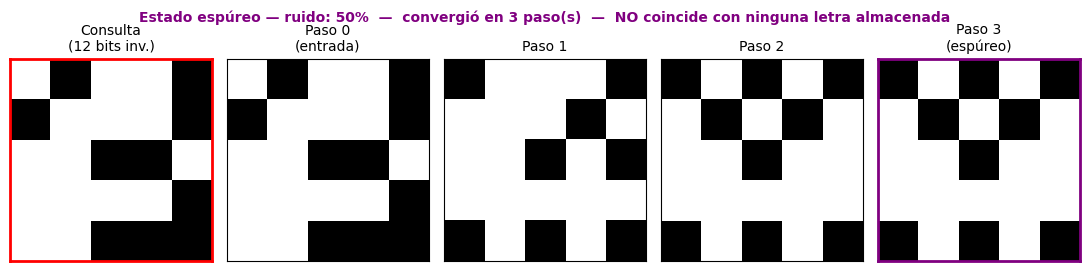

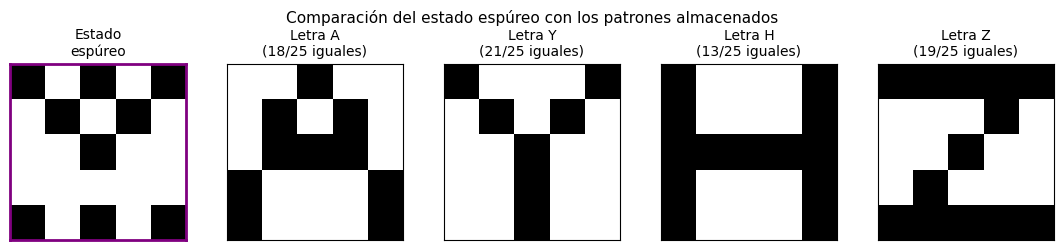

In [11]:
if result:
    n_show_b = min(len(history_b), 7)
    step_indices_b = np.linspace(0, len(history_b) - 1, n_show_b, dtype=int)

    fig, axes = plt.subplots(1, n_show_b + 1, figsize=(2.2 * (n_show_b + 1), 2.8))

    plot_pattern(axes[0], noisy_b,
                 title=f'Consulta\n({n_bits_b} bits inv.)')
    axes[0].spines[:].set_color('red')
    for spine in axes[0].spines.values():
        spine.set_linewidth(2)

    for k, idx in enumerate(step_indices_b):
        ax = axes[k + 1]
        label = f'Paso {idx}' if idx > 0 else 'Paso 0\n(entrada)'
        if idx == len(history_b) - 1:
            label = f'Paso {idx}\n(espúreo)'
        plot_pattern(ax, history_b[idx], title=label)
        if idx == len(history_b) - 1:
            ax.spines[:].set_color('purple')
            for spine in ax.spines.values():
                spine.set_linewidth(2)

    fig.suptitle(
        f'Estado espúreo — ruido: {int(noise_b*100)}%  —  '
        f'convergió en {n_steps_b} paso(s)  —  NO coincide con ninguna letra almacenada',
        fontsize=10, fontweight='bold', color='purple'
    )
    plt.tight_layout()
    plt.show()

    # Mostrar los 4 patrones almacenados para comparar
    fig2, axes2 = plt.subplots(1, 5, figsize=(11, 2.5))
    plot_pattern(axes2[0], final_b, title='Estado\nespúreo')
    axes2[0].spines[:].set_color('purple')
    for spine in axes2[0].spines.values():
        spine.set_linewidth(2)
    for ax, name, xi in zip(axes2[1:], pattern_names, pattern_list):
        sim = int(np.sum(final_b == xi))
        plot_pattern(ax, xi, title=f'Letra {name}\n({sim}/25 iguales)')
    fig2.suptitle('Comparación del estado espúreo con los patrones almacenados', fontsize=11)
    plt.tight_layout()
    plt.show()

## 5. Análisis de resultados

### Parte a — Recuperación con ruido moderado (20%)

Con el 20% de bits invertidos (5 de 25), la red de Hopfield recupera correctamente los 4 patrones almacenados. Esto es esperable: la red actúa como memoria asociativa y puede corregir errores menores gracias a la redundancia codificada en la matriz de pesos.

La actualización asíncrona converge rápidamente (típicamente en 1-3 pasos), porque cada neurona corrige su estado basándose en el campo local `h_i = Σ_j W_ij · s_j`.

### Parte b — Estado espúreo con ruido alto (≥50%)

Con ruido muy alto, el patrón de consulta queda fuera de la cuenca de atracción de cualquier patrón almacenado. La red converge igualmente (la energía siempre decrece), pero a un **estado espúreo**: un mínimo de la función de energía que no fue explícitamente memorizado.

Los estados espúreos más comunes en redes de Hopfield son:
- **Mixed states**: `sign(ξ¹ + ξ² + ξ³)` — combinación de 3 patrones. Son atractores espúreos conocidos teóricamente.
- **Patrones invertidos**: `-ξ^μ` — el negativo de un patrón almacenado también es siempre un atractor.
- **Spin-glass states**: atractores que emergen puramente del ruido en la matriz de pesos.

### ¿Por qué existen los estados espúreos?

La red de Hopfield almacena patrones como **mínimos de energía**, pero la función de energía puede tener **mínimos locales adicionales** no planeados. Cuantos más patrones se almacenan (acercándose a la capacidad de 0.138·N), más estados espúreos aparecen.